# Composition Sensitivity Analysis — Multi-Alloy

**Repository**: matreum/am-solidification-screening | **Notebook 03**

## Purpose

Demonstrate how minor element variation within specification ranges affects
solidification behavior and cracking susceptibility. This bridges thermodynamics to real
manufacturing — powder lot variation, evaporation losses, and composition drift are facts
of AM production, and this analysis quantifies their effect.

### Alloys Analyzed

| Alloy | Swept Elements | Database | Specification |
|-------|---------------|----------|---------------|
| 316L SS | Cr, Ni | Fe-Cr-Ni ternary (Miettinen 1999) | ASTM A240 |
| AlSi10Mg | Si, Mg | COST 507 (corrected) | EN AC-43000 |
| IN718 | Nb, Cr | steel_database_fix.tdb | AMS 5662 |
| Ti-6Al-4V | Al, V | COST 507 (corrected) | AMS 4928 |

### Approach

One-element-at-a-time sweeps: vary one element while holding others at nominal values.
Extract solidification range (ΔT) and Kou cracking index at each composition point.

In [ ]:
import sys, os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'src'))

from pycalphad import variables as v
from matreum_am_screening.core import AlloySystem, composition_sweep, ALLOY_ALSI10MG, ALLOY_IN718, ALLOY_TI64
from matreum_am_screening.plotting import plot_sensitivity_curves, plot_tornado

plt.rcParams['figure.dpi'] = 120

DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), 'data', 'published')

# --- 316L: Fe-Cr-Ni ternary for sweep speed ---
ALLOY_316L_TERNARY = AlloySystem(
    name="316L (Fe-Cr-Ni)",
    components=["FE", "CR", "NI", "VA"],
    phases=["LIQUID", "FCC_A1", "BCC_A2", "HCP_A3", "SIGMA"],
    composition={v.X("CR"): 0.179, v.X("NI"): 0.112},
    db_path=os.path.join(DATA_DIR, "crfeni_mie.tdb"),
    start_temperature=1800.0,
)

print("Dependencies loaded.")

---

## 1. 316L Stainless Steel

316L (ASTM A240) specification ranges:
- Cr: 16.0–18.0 wt% → ~0.168–0.190 mol fraction
- Ni: 10.0–14.0 wt% → ~0.093–0.131 mol fraction

### Chromium Sweep (Cr: 0.168 → 0.190 mol fraction)

Chromium has the largest specification range in 316L. It controls the ferrite/austenite
balance during solidification. Crossing the critical Cr_eq/Ni_eq ratio can switch the
primary solidification phase from austenite to delta ferrite.

> **Note**: Sweeps use the Fe-Cr-Ni ternary database (Miettinen 1999) for computational
> efficiency. The ternary captures the primary solidification mode transition but does not
> include C, Mo, Mn, Si effects.

In [2]:
print("Running Cr sweep (5 points)...")
cr_sweep = composition_sweep(
    ALLOY_316L_TERNARY, element="CR",
    x_range=np.linspace(0.168, 0.190, 5),
    step_temperature=2.0,
)
print("Done!")
print(cr_sweep[["x_CR", "T_liquidus_C", "T_solidus_C", "delta_T_C", "CSC_Kou"]].to_string(index=False))

Running Cr sweep (5 points)...


Done!
  x_CR  T_liquidus_C  T_solidus_C  delta_T_C     CSC_Kou
0.1680       1430.85      1276.85      154.0 3351.867770
0.1735       1426.85      1276.85      150.0 3284.227363
0.1790       1424.85      1274.85      150.0 3530.362228
0.1845       1422.85      1274.85      148.0 3475.265984
0.1900       1420.85      1274.85      146.0 3140.761485


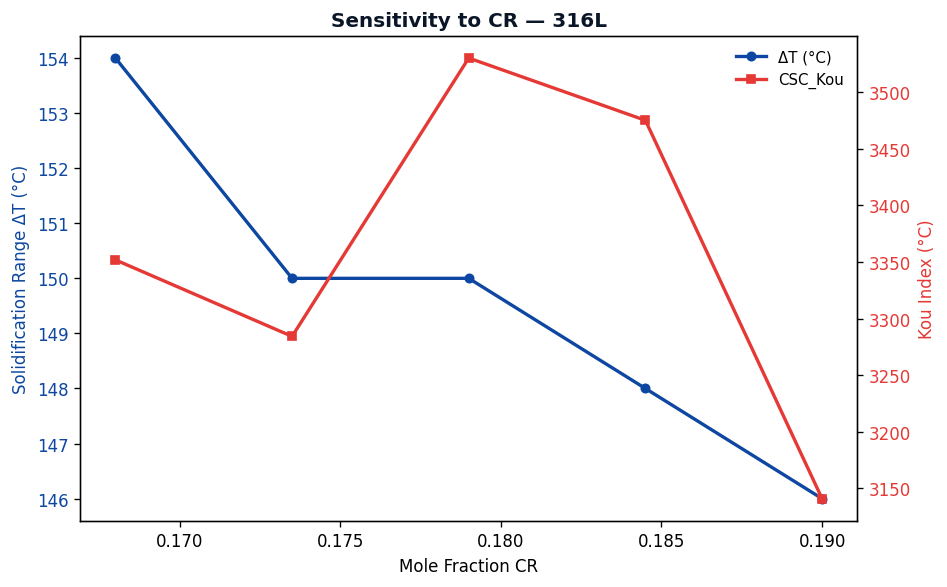

In [3]:
fig = plot_sensitivity_curves(cr_sweep, "CR")
plt.show()

### Nickel Sweep (Ni: 0.093 → 0.131 mol fraction)

Nickel is the primary austenite stabilizer. Higher Ni pushes solidification toward the
austenitic (AF) mode, generally increasing cracking susceptibility.

In [4]:
print("Running Ni sweep (5 points)...")
ni_sweep = composition_sweep(
    ALLOY_316L_TERNARY, element="NI",
    x_range=np.linspace(0.093, 0.131, 5),
    step_temperature=2.0,
)
print("Done!")
print(ni_sweep[["x_NI", "T_liquidus_C", "T_solidus_C", "delta_T_C", "CSC_Kou"]].to_string(index=False))

Running Ni sweep (5 points)...


Done!
  x_NI  T_liquidus_C  T_solidus_C  delta_T_C     CSC_Kou
0.0930       1438.85      1278.85      160.0 3657.143372
0.1025       1430.85      1276.85      154.0 3534.245241
0.1120       1424.85      1274.85      150.0 3530.362228
0.1215       1420.85      1274.85      146.0 3261.566274
0.1310       1416.85      1272.85      144.0 2997.996373


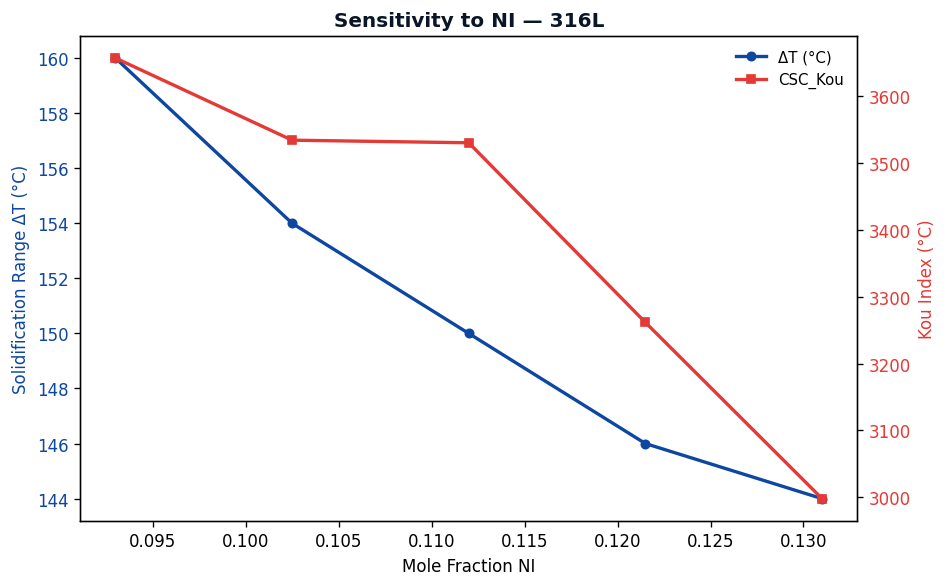

In [5]:
fig = plot_sensitivity_curves(ni_sweep, "NI")
plt.show()

### 316L Tornado Chart — Which Element Dominates?

The tornado chart shows the total variation in solidification range (ΔT) across each
element's specification range. The longest bar indicates which element has the largest
effect on cracking susceptibility.

In [ ]:
sensitivities_316L = {}
for name, sweep_df, col in [("Cr", cr_sweep, "delta_T_C"),
                              ("Ni", ni_sweep, "delta_T_C")]:
    valid = sweep_df[col].dropna()
    if len(valid) > 0:
        sensitivities_316L[name] = (valid.min(), valid.max())

fig = plot_tornado(sensitivities_316L)
plt.show()

print("\n316L Sensitivity Summary:")
print(f"{'Element':<10} {'ΔT min (°C)':>12} {'ΔT max (°C)':>12} {'Range (°C)':>12}")
print("-" * 48)
for el, (lo, hi) in sorted(sensitivities_316L.items(), key=lambda x: abs(x[1][1]-x[1][0]), reverse=True):
    print(f"{el:<10} {lo:>12.1f} {hi:>12.1f} {abs(hi-lo):>12.1f}")

---

## 2. AlSi10Mg

AlSi10Mg (EN AC-43000) specification ranges:
- Si: 9.0–11.0 wt% → ~0.088–0.107 mol fraction
- Mg: 0.20–0.45 wt% → ~0.002–0.005 mol fraction

Silicon is the dominant alloying element and controls the eutectic reaction. Higher Si
narrows the solidification range and promotes the Al-Si eutectic, which acts as a
"healing" phase that backfills nascent cracks. Mg forms Mg₂Si strengthening precipitates
but has minimal effect on solidification range at these low levels.

### Silicon Sweep (Si: 0.088 → 0.107 mol fraction)

In [ ]:
print("Running Si sweep (5 points)...")
si_sweep = composition_sweep(
    ALLOY_ALSI10MG, element="SI",
    x_range=np.linspace(0.088, 0.107, 5),
    step_temperature=1.0,
)
print("Done!")
print(si_sweep[["x_SI", "T_liquidus_C", "T_solidus_C", "delta_T_C", "CSC_Kou"]].to_string(index=False))

In [ ]:
fig = plot_sensitivity_curves(si_sweep, "SI", alloy_name="AlSi10Mg")
plt.show()

### Magnesium Sweep (Mg: 0.002 → 0.005 mol fraction)

Magnesium forms Mg₂Si during terminal solidification. At these low concentrations,
the effect on solidification range is expected to be small relative to Si.

In [ ]:
print("Running Mg sweep (5 points)...")
mg_sweep = composition_sweep(
    ALLOY_ALSI10MG, element="MG",
    x_range=np.linspace(0.002, 0.005, 5),
    step_temperature=1.0,
)
print("Done!")
print(mg_sweep[["x_MG", "T_liquidus_C", "T_solidus_C", "delta_T_C", "CSC_Kou"]].to_string(index=False))

In [ ]:
fig = plot_sensitivity_curves(mg_sweep, "MG", alloy_name="AlSi10Mg")
plt.show()

### AlSi10Mg Tornado Chart

In [ ]:
sensitivities_alsi = {}
for name, sweep_df, col in [("Si", si_sweep, "delta_T_C"),
                              ("Mg", mg_sweep, "delta_T_C")]:
    valid = sweep_df[col].dropna()
    if len(valid) > 0:
        sensitivities_alsi[name] = (valid.min(), valid.max())

fig = plot_tornado(sensitivities_alsi)
plt.show()

print("\nAlSi10Mg Sensitivity Summary:")
print(f"{'Element':<10} {'ΔT min (°C)':>12} {'ΔT max (°C)':>12} {'Range (°C)':>12}")
print("-" * 48)
for el, (lo, hi) in sorted(sensitivities_alsi.items(), key=lambda x: abs(x[1][1]-x[1][0]), reverse=True):
    print(f"{el:<10} {lo:>12.1f} {hi:>12.1f} {abs(hi-lo):>12.1f}")

---

## 3. IN718 (Inconel 718)

IN718 (AMS 5662) specification ranges:
- Nb: 4.75–5.50 wt% → ~0.029–0.034 mol fraction (Nb+Ta)
- Cr: 17.0–21.0 wt% → ~0.185–0.227 mol fraction

Niobium is the critical element for IN718 solidification cracking. It drives Laves phase
and NbC eutectic formation at terminal solidification, widening the solidification range.
Small changes in Nb content can significantly alter the amount of terminal eutectic and
thus cracking susceptibility.

### Niobium Sweep (Nb: 0.029 → 0.034 mol fraction)

> **Note**: IN718 sweeps use the full 9-component system (steel_database_fix.tdb) with
> step_temperature=5.0 K for computational efficiency. This coarser step is necessary
> due to the complexity of the 9-component thermodynamic calculation.

In [ ]:
print("Running Nb sweep (5 points)...")
nb_sweep = composition_sweep(
    ALLOY_IN718, element="NB",
    x_range=np.linspace(0.029, 0.034, 5),
    step_temperature=5.0,
)
print("Done!")
print(nb_sweep[["x_NB", "T_liquidus_C", "T_solidus_C", "delta_T_C", "CSC_Kou"]].to_string(index=False))

In [ ]:
fig = plot_sensitivity_curves(nb_sweep, "NB", alloy_name="IN718")
plt.show()

### Chromium Sweep (Cr: 0.185 → 0.227 mol fraction)

Chromium affects the matrix FCC stability and can influence the amount of secondary
phase formation, though its effect on solidification range is typically secondary
to Nb in IN718.

In [ ]:
print("Running Cr sweep for IN718 (5 points)...")
cr_in718_sweep = composition_sweep(
    ALLOY_IN718, element="CR",
    x_range=np.linspace(0.185, 0.227, 5),
    step_temperature=5.0,
)
print("Done!")
print(cr_in718_sweep[["x_CR", "T_liquidus_C", "T_solidus_C", "delta_T_C", "CSC_Kou"]].to_string(index=False))

In [ ]:
fig = plot_sensitivity_curves(cr_in718_sweep, "CR", alloy_name="IN718")
plt.show()

### IN718 Tornado Chart

In [ ]:
sensitivities_in718 = {}
for name, sweep_df, col in [("Nb", nb_sweep, "delta_T_C"),
                              ("Cr", cr_in718_sweep, "delta_T_C")]:
    valid = sweep_df[col].dropna()
    if len(valid) > 0:
        sensitivities_in718[name] = (valid.min(), valid.max())

fig = plot_tornado(sensitivities_in718)
plt.show()

print("\nIN718 Sensitivity Summary:")
print(f"{'Element':<10} {'ΔT min (°C)':>12} {'ΔT max (°C)':>12} {'Range (°C)':>12}")
print("-" * 48)
for el, (lo, hi) in sorted(sensitivities_in718.items(), key=lambda x: abs(x[1][1]-x[1][0]), reverse=True):
    print(f"{el:<10} {lo:>12.1f} {hi:>12.1f} {abs(hi-lo):>12.1f}")

---

## 4. Ti-6Al-4V (Grade 5 Titanium)

Ti-6Al-4V (AMS 4928) specification ranges:
- Al: 5.50–6.75 wt% → ~0.096–0.117 mol fraction
- V: 3.50–4.50 wt% → ~0.032–0.042 mol fraction

Aluminum is the primary alpha stabilizer and controls the beta transus temperature.
Vanadium is the primary beta stabilizer. Both elements affect the solidification path,
though Ti-6Al-4V has a narrow solidification range regardless of composition variation
due to its single-phase BCC solidification.

### Aluminum Sweep (Al: 0.096 → 0.117 mol fraction)

In [ ]:
print("Running Al sweep (5 points)...")
al_sweep = composition_sweep(
    ALLOY_TI64, element="AL",
    x_range=np.linspace(0.096, 0.117, 5),
    step_temperature=1.0,
)
print("Done!")
print(al_sweep[["x_AL", "T_liquidus_C", "T_solidus_C", "delta_T_C", "CSC_Kou"]].to_string(index=False))

In [ ]:
fig = plot_sensitivity_curves(al_sweep, "AL", alloy_name="Ti-6Al-4V")
plt.show()

### Vanadium Sweep (V: 0.032 → 0.042 mol fraction)

Vanadium is the beta stabilizer. Its effect on solidification range is expected to be
modest since Ti-6Al-4V solidifies through a single BCC phase.

In [ ]:
print("Running V sweep (5 points)...")
v_sweep = composition_sweep(
    ALLOY_TI64, element="V",
    x_range=np.linspace(0.032, 0.042, 5),
    step_temperature=1.0,
)
print("Done!")
print(v_sweep[["x_V", "T_liquidus_C", "T_solidus_C", "delta_T_C", "CSC_Kou"]].to_string(index=False))

In [ ]:
fig = plot_sensitivity_curves(v_sweep, "V", alloy_name="Ti-6Al-4V")
plt.show()

### Ti-6Al-4V Tornado Chart

In [ ]:
sensitivities_ti64 = {}
for name, sweep_df, col in [("Al", al_sweep, "delta_T_C"),
                              ("V", v_sweep, "delta_T_C")]:
    valid = sweep_df[col].dropna()
    if len(valid) > 0:
        sensitivities_ti64[name] = (valid.min(), valid.max())

fig = plot_tornado(sensitivities_ti64)
plt.show()

print("\nTi-6Al-4V Sensitivity Summary:")
print(f"{'Element':<10} {'ΔT min (°C)':>12} {'ΔT max (°C)':>12} {'Range (°C)':>12}")
print("-" * 48)
for el, (lo, hi) in sorted(sensitivities_ti64.items(), key=lambda x: abs(x[1][1]-x[1][0]), reverse=True):
    print(f"{el:<10} {lo:>12.1f} {hi:>12.1f} {abs(hi-lo):>12.1f}")

## Stated Limitations

1. **316L uses a ternary database for sweep speed.** The Fe-Cr-Ni ternary (Miettinen 1999)
   captures the primary solidification mode transition but omits C, Mo, Mn, Si effects.
   For quantitative assessment, use the full 7-component steel database with individual
   compositions of interest.

2. **One-at-a-time sweeps do not capture interactions.** Element interactions (e.g., Cr-Ni
   in 316L, Nb-Ti in IN718) can be significant. A full factorial design would capture these
   but requires more simulations.

3. **Specification range ≠ production range.** Actual powder lot variation is typically
   tighter. A ±1σ production range from powder supplier COAs would be more realistic.

4. **Evaporation not modeled.** LPBF causes preferential evaporation of volatile elements
   (Mn, Cr in steels; Mg, Al in aluminum alloys) from the melt pool.

5. **No process parameter coupling.** Solidification behavior depends on composition AND
   process parameters (power, speed, layer thickness).

6. **Open-source databases.** IN718 results use the general-purpose steel_database_fix.tdb
   rather than a Ni-base-specific commercial database (TCNI, TTNi). Ti-6Al-4V results use
   COST 507 rather than a Ti-specific database (TCTI, PanTi). Relative trends are more
   reliable than absolute values.

---
*Matreum LLC — AM Solidification Screening, 2026*